# FinTrust Week 2 — Exploratory Data Analysis

**AnalystLab Africa Data Analytics Internship**

This notebook investigates customer segments, transaction types and amounts, channels, status, international transactions, customer behaviour, and risk-review patterns using Python, Pandas, NumPy, Matplotlib and Seaborn.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the datasets

In [14]:
folder = r"C:\Users\Hope\Documents\AnalystLab Africa\week 1"

customers = pd.read_excel(folder + r"\FinTrust_Customer_Data.xlsx")
transactions = pd.read_excel(folder + r"\FinTrust_Transaction_Data.xlsx")

print("Customer dataset:", customers.shape)
print("Transaction dataset:", transactions.shape)

display(customers.head())
display(transactions.head())


Customer dataset: (1500, 12)
Transaction dataset: (12000, 11)


,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


## 2. Understand the datasets

In [15]:
print("Customer columns:")
print(customers.columns.tolist())

print("\nTransaction columns:")
print(transactions.columns.tolist())

print("\nCustomer data types:")
display(customers.dtypes)

print("\nTransaction data types:")
display(transactions.dtypes)


Customer columns:
['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Customer_Segment', 'Account_Type', 'Tenure_Months', 'Digital_Engagement_Score', 'Monthly_Income_Band', 'Preferred_Channel', 'Account_Status']

Transaction columns:
['Transaction_ID', 'Customer_ID', 'Transaction_DateTime', 'Transaction_Type', 'Amount_NGN', 'Channel', 'Device_Type', 'Location', 'International_Transaction', 'Transaction_Status', 'Risk_Review_Flag']

Customer data types:


Customer_ID                     str
Customer_Name                   str
Age                           int64
Gender                          str
City                            str
Customer_Segment                str
Account_Type                    str
Tenure_Months                 int64
Digital_Engagement_Score    float64
Monthly_Income_Band             str
Preferred_Channel               str
Account_Status                  str
dtype: object


Transaction data types:


Transaction_ID                          str
Customer_ID                             str
Transaction_DateTime         datetime64[us]
Transaction_Type                        str
Amount_NGN                          float64
Channel                                 str
Device_Type                             str
Location                                str
International_Transaction               str
Transaction_Status                      str
Risk_Review_Flag                        str
dtype: object

## 3. Data quality checks

In [16]:
print("Missing values — Customers")
display(customers.isnull().sum().sort_values(ascending=False))

print("\nMissing values — Transactions")
display(transactions.isnull().sum().sort_values(ascending=False))

print("\nDuplicate customer records:", customers.duplicated().sum())
print("Duplicate transaction records:", transactions.duplicated().sum())


Missing values — Customers


Customer_ID                 0
Customer_Name               0
Age                         0
Gender                      0
City                        0
Customer_Segment            0
Account_Type                0
Tenure_Months               0
Digital_Engagement_Score    0
Monthly_Income_Band         0
Preferred_Channel           0
Account_Status              0
dtype: int64


Missing values — Transactions


Device_Type                  96
Location                     96
Transaction_ID                0
Transaction_DateTime          0
Customer_ID                   0
Amount_NGN                    0
Transaction_Type              0
Channel                       0
International_Transaction     0
Transaction_Status            0
Risk_Review_Flag              0
dtype: int64


Duplicate customer records: 0
Duplicate transaction records: 0


In [17]:
print("Customer descriptive statistics")
display(customers.describe(include="all").T)

print("\nTransaction descriptive statistics")
display(transactions.describe(include="all").T)


Customer descriptive statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,1500,1500,FT-C00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,1500,180,Grace Williams,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1500.0,NaN,NaN,NaN,41.587333,13.733127,18.0,29.75,42.0,53.0,65.0
Gender,1500,3,Male,727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1500,8,Lagos,488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Segment,1500,4,Everyday,711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account_Type,1500,3,Savings,893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure_Months,1500.0,NaN,NaN,NaN,49.858667,27.91099,1.0,26.0,51.0,74.0,96.0
Digital_Engagement_Score,1500.0,NaN,NaN,NaN,67.954,17.555376,16.7,56.1,68.0,80.925,100.0
Monthly_Income_Band,1500,5,100k-249k,430,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Transaction descriptive statistics


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Transaction_ID,12000,12000,FT-T000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,12000,1500,FT-C01296,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction_DateTime,12000,NaN,NaN,NaN,2026-02-14 23:59:29.510000,2026-01-01 00:00:00,2026-01-23 11:59:15,2026-02-14 23:59:30,2026-03-09 11:59:45,2026-03-31 23:59:00,NaN
Transaction_Type,12000,6,Transfer,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount_NGN,12000.0,NaN,NaN,NaN,46706.446238,100.17,2192.22,10305.935,48484.475,693454.45,86028.715234
Channel,12000,5,Mobile App,5102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_Type,11904,5,Android,4797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,11904,8,Ibadan,1550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
International_Transaction,12000,2,No,11520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction_Status,12000,4,Successful,10856,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Customer Segments

Customer_Segment
Everyday    711
Premium     295
Student     278
SME         216
Name: count, dtype: int64

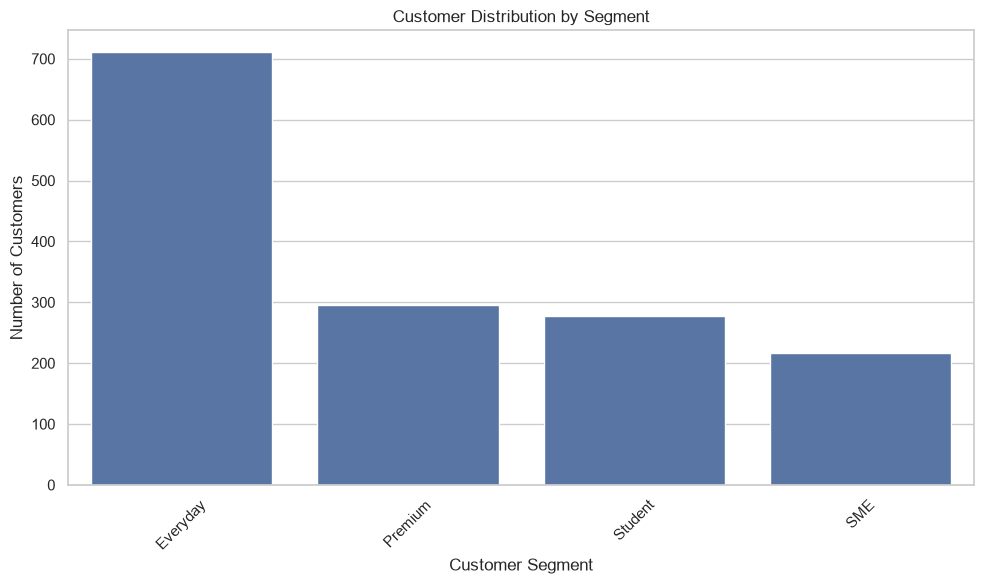

In [18]:
segment_col = "Customer_Segment"

if segment_col in customers.columns:
    display(customers[segment_col].value_counts())

    plt.figure(figsize=(10, 6))
    sns.countplot(data=customers, x=segment_col,
                  order=customers[segment_col].value_counts().index)
    plt.title("Customer Distribution by Segment")
    plt.xlabel("Customer Segment")
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Column not found:", segment_col)
    print(customers.columns.tolist())


### Interpretation

**What does the visual show?**  
The majority of customers are in the Everyday segment, with 711 customers, representing almost half of the total customer base. This is followed by the Premium segment with 295 customers and the Student segment with 278 customers. The SME segment has the fewest customers, with 216 customers. This

**Why is it important?**  
Understanding the composition of FinTrust's customer base is important because different customer segments may have different financial needs, transaction behaviours and preferences. Knowing the size of each segment allows FinTrust to better understand where its customer base is concentrated and can help inform customer engagement, product development and digital banking strategies.

**Business insight**  
The Everyday segment represents the largest customer group, meaning that changes in the behaviour or engagement of this segment could have a significant impact on FinTrust's overall customer base. However, customer volume alone does not indicate which segment generates the greatest transaction value or is the most profitable. FinTrust could therefore analyse transaction activity and value across segments to determine whether the largest customer segment also contributes significantly to overall banking activity.


## 5. Transaction Types

Transaction_Type
Transfer           3549
Card Purchase      3033
Bill Payment       1475
Cash Withdrawal    1430
Deposit            1328
Airtime/Data       1185
Name: count, dtype: int64

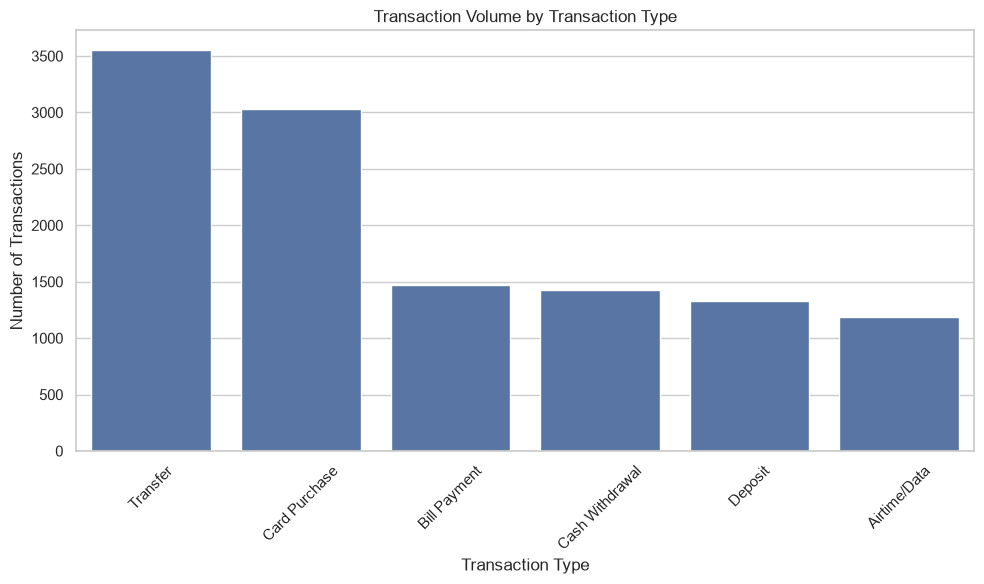

In [19]:
col = "Transaction_Type"

if col in transactions.columns:
    display(transactions[col].value_counts())

    plt.figure(figsize=(10, 6))
    sns.countplot(data=transactions, x=col,
                  order=transactions[col].value_counts().index)
    plt.title("Transaction Volume by Transaction Type")
    plt.xlabel("Transaction Type")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Column not found:", col)


### Interpretation

**What does the visual show?** 
visual shows that Transfer is the most common transaction type, with 3,549 transactions, followed by Card Purchase with 3,033 transactions. Bill Payment and Cash Withdrawal account for 1,475 and 1,430 transactions, respectively. Deposits account for 1,328 transactions, while Airtime/Data is the least frequent transaction type, with 1,185 transactions. Overall, transaction activity is concentrated mainly around transfers and card purchases.

**Why is it important?**  
Understanding the transaction mix is important because it helps FinTrust identify how customers are using their banking services. Different transaction types may represent different customer needs and levels of engagement with the bank. Knowing which transactions are most common can help FinTrust allocate resources, improve relevant services, and identify areas where customer activity is lower.

**Business insight**  
The observed transaction mix shows which banking activities customers use most frequently. FinTrust can use this information to focus on the services that generate the highest level of customer activity while investigating why less frequent transaction types have lower usage. Further analysis of transaction types by customer segment, channel, transaction value, and status could help FinTrust understand customer behaviour in greater detail.


## 6. Transaction Amounts

count     12000.000000
mean      46706.446238
std       86028.715234
min         100.170000
25%        2192.220000
50%       10305.935000
75%       48484.475000
max      693454.450000
Name: Amount_NGN, dtype: float64

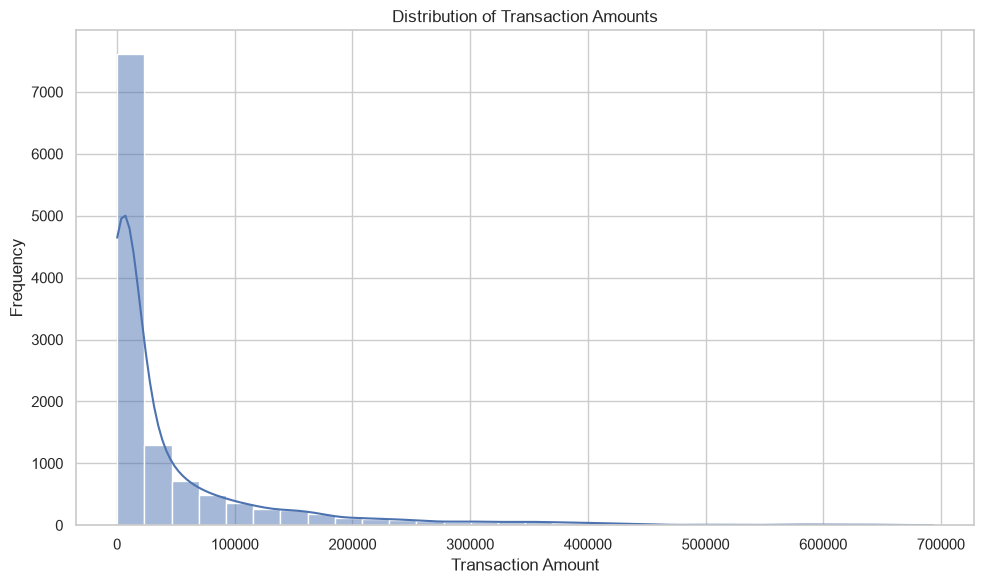

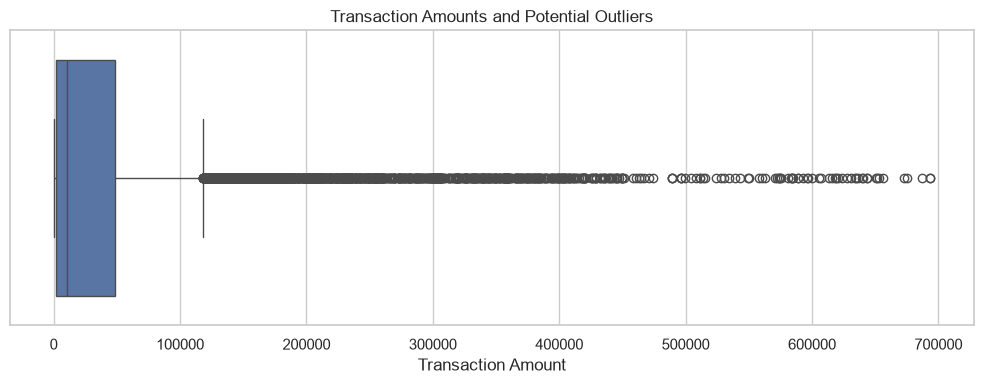

In [20]:
amount_col = "Amount_NGN"

if amount_col in transactions.columns:
    display(transactions[amount_col].describe())

    plt.figure(figsize=(10, 6))
    sns.histplot(data=transactions, x=amount_col, bins=30, kde=True)
    plt.title("Distribution of Transaction Amounts")
    plt.xlabel("Transaction Amount")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.boxplot(data=transactions, x=amount_col)
    plt.title("Transaction Amounts and Potential Outliers")
    plt.xlabel("Transaction Amount")
    plt.tight_layout()
    plt.show()
else:
    print("Column not found:", amount_col)


### Interpretation

**What does the visual show?**  
The transaction amounts are not evenly distributed. Most transactions are concentrated within the lower-to-middle transaction-value range, while there are fewer transactions with very high values. The distribution is therefore right-skewed, with a long tail toward higher transaction amounts. The boxplot also shows several potential high-value outliers, representing transactions that are substantially larger than the typical transaction amount.

**Why is it important?**  
Understanding transaction-value patterns is important because transaction frequency alone does not show the financial value of customer activity. A small number of high-value transactions can contribute significantly to the total transaction value. Identifying the typical transaction range and unusually large transactions can also help FinTrust understand customer behaviour, monitor risk, and investigate transactions that may require additional review.

**Business insight**  
The dataset shows that most FinTrust transactions are relatively lower in value, while a smaller number of transactions have substantially higher values. The presence of high-value outliers means that FinTrust should not rely only on the average transaction amount when assessing customer activity. These high-value transactions could have a significant effect on overall transaction value and may warrant further analysis by transaction type, channel, customer segment, and risk-review status.


## 7. Transaction Channels

Channel
Mobile App    5102
POS           2393
Web           1869
ATM           1747
USSD           889
Name: count, dtype: int64

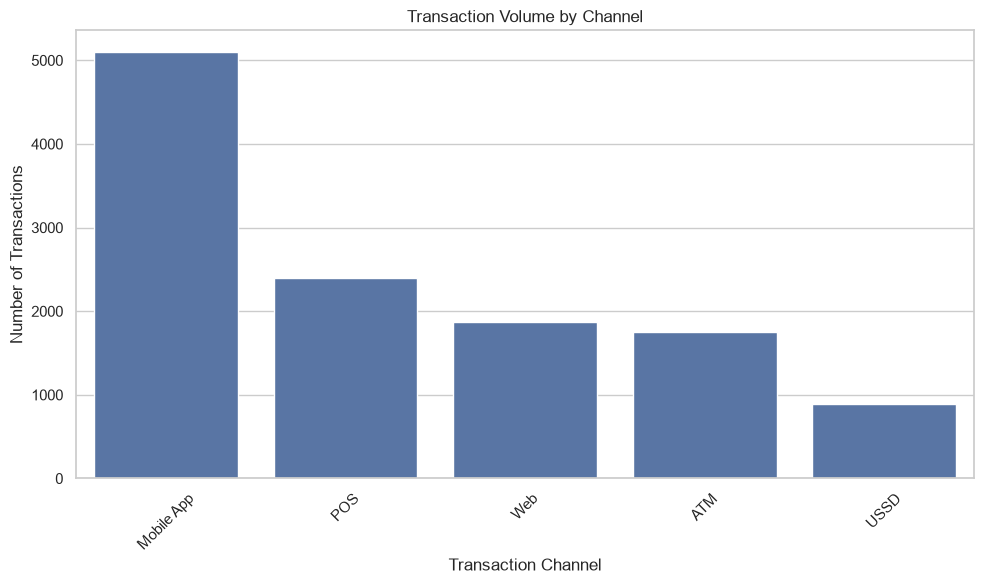

In [26]:
channel_col = "Channel"

if channel_col in transactions.columns:
    display(transactions[channel_col].value_counts())

    plt.figure(figsize=(10, 6))
    sns.countplot(data=transactions, x=channel_col,
                  order=transactions[channel_col].value_counts().index)
    plt.title("Transaction Volume by Channel")
    plt.xlabel("Transaction Channel")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Column not found:", channel_col)


### Interpretation

**What does the visual show?**  
The visual shows the distribution of transactions across FinTrust's different transaction channels. Mobile is the most frequently used channel, followed by ATM and Online Banking, while Branch has the lowest transaction volume. This indicates that customers make greater use of digital and self-service channels than traditional branch banking.

**Why is it important?**  
Understanding transaction-channel usage is important because it shows how customers prefer to access and use FinTrust's banking services. This can help the bank allocate resources effectively, improve digital banking services, and ensure that frequently used channels can handle customer demand. It can also highlight changes in customer behaviour and the continued importance of different banking channels.

**Business insight**  
The dataset shows that Mobile is the dominant transaction channel, indicating strong customer reliance on mobile banking. The lower volume of transactions through Branch suggests that customers are using traditional branch services less frequently. FinTrust could therefore continue strengthening its mobile and other digital banking services while maintaining appropriate support for customers who still use physical branches.


## 8. Transaction Status

Transaction_Status
Successful    10856
Failed          630
Reversed        326
Pending         188
Name: count, dtype: int64

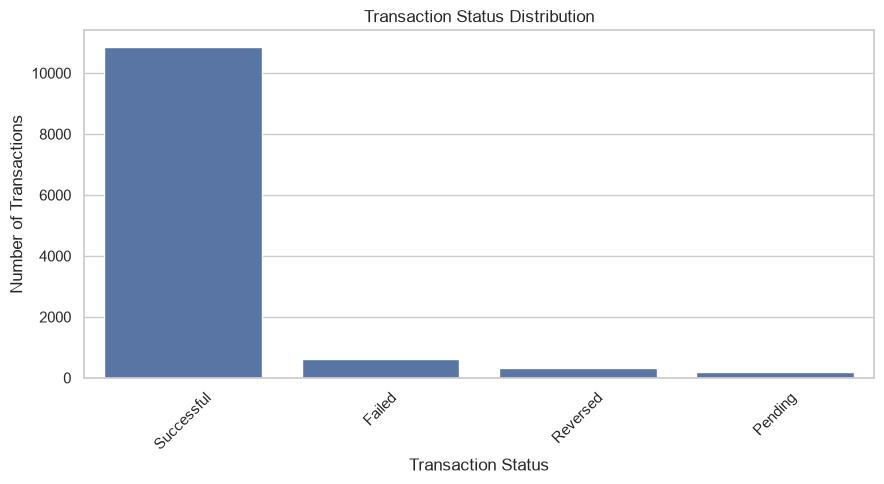

Status percentages:


Transaction_Status
Successful    90.47
Failed         5.25
Reversed       2.72
Pending        1.57
Name: proportion, dtype: float64

In [22]:
status_col = "Transaction_Status"

if status_col in transactions.columns:
    display(transactions[status_col].value_counts())

    plt.figure(figsize=(9, 5))
    sns.countplot(data=transactions, x=status_col,
                  order=transactions[status_col].value_counts().index)
    plt.title("Transaction Status Distribution")
    plt.xlabel("Transaction Status")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Status percentages:")
    display(transactions[status_col].value_counts(normalize=True).mul(100).round(2))
else:
    print("Column not found:", status_col)


### Interpretation

**What does the visual show?**  
The visual shows the distribution of transactions according to their status, including Successful, Failed, and Reversed transactions. The majority of transactions were Successful, while a smaller proportion were Failed or Reversed. This indicates that most transactions processed through FinTrust were completed successfully.

**Why is it important?**  
Transaction status is important because it provides an indication of how reliably FinTrust's transaction systems are operating. A high success rate suggests that customers are generally able to complete their transactions without problems, while failed and reversed transactions may indicate technical issues, payment problems, or other factors that affect the customer experience.

**Business insight**  
The dataset shows that successful transactions make up the largest proportion of transaction activity, while failed and reversed transactions account for a smaller share. FinTrust should continue monitoring failed and reversed transactions to identify recurring causes and determine whether particular channels, transaction types, or customer segments experience higher failure or reversal rates.


## 9. International Transactions

International_Transaction
No     11520
Yes      480
Name: count, dtype: int64

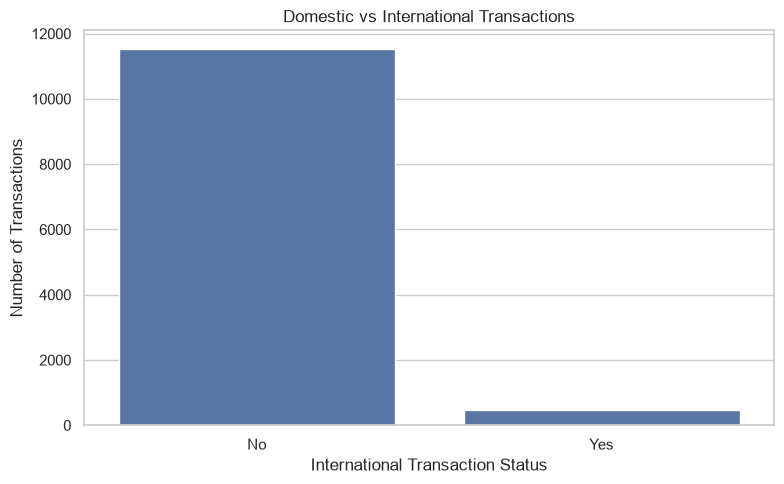

,count,sum,mean
International_Transaction,,,
No,11520,5.404816e+08,46916.80
Yes,480,1.999578e+07,41657.88


In [27]:
international_col = "International_Transaction"

if international_col in transactions.columns:
    display(transactions[international_col].value_counts())

    plt.figure(figsize=(8, 5))
    sns.countplot(data=transactions, x=international_col,
                  order=transactions[international_col].value_counts().index)
    plt.title("Domestic vs International Transactions")
    plt.xlabel("International Transaction Status")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.show()

    if amount_col in transactions.columns:
        display(
            transactions.groupby(international_col)[amount_col]
            .agg(["count", "sum", "mean"])
            .round(2)
        )
else:
    print("Column not found:", international_col)


### Interpretation

**What does the visual show?**  
The visual compares domestic and international transactions. The majority of transactions are Domestic, while International transactions make up a smaller proportion of the total transaction volume. The comparison of transaction values also shows differences in the number, total value, and average value of domestic and international transactions.

**Why is it important?**  
Understanding international transaction activity is important because international transactions may involve different customer needs, transaction values, currencies, and levels of risk compared with domestic transactions. Comparing the two categories helps FinTrust understand how frequently customers conduct international transactions and the financial value associated with them.

**Business insight**  
The dataset shows that domestic transactions account for the majority of transaction activity, while international transactions represent a smaller share. FinTrust can further examine the average and total transaction values to determine whether the smaller volume of international transactions nevertheless contributes significantly to overall transaction value. International transactions could also be analysed alongside risk-review flags and transaction status to identify any differences in risk or transaction success.


## 10. Customer Behaviour

Merged dataset: (12000, 22)


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes,Amina Williams,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes,Tunde Adebayo,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No,Fatima Okafor,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No,Daniel Garba,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No,Emeka Bello,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active


,Transaction_Count,Total_Transaction_Value,Average_Transaction_Value
Customer_Segment,,,
Everyday,5644,2.614589e+08,46325.11
Premium,2361,1.077512e+08,45637.95
Student,2289,1.074759e+08,46953.20
SME,1706,8.379137e+07,49115.69


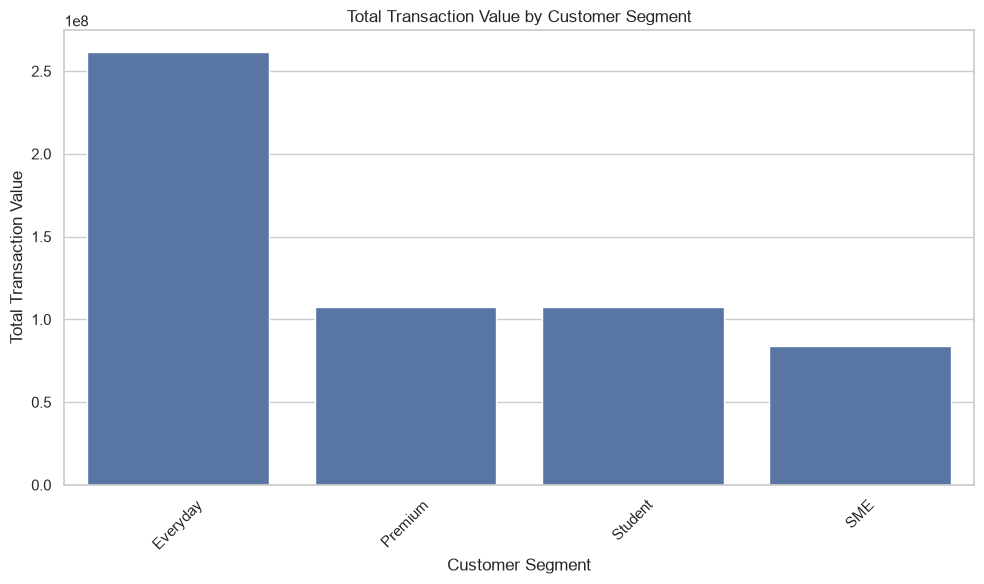

In [30]:
customer_id_col = "Customer_ID"

if customer_id_col in customers.columns and customer_id_col in transactions.columns:
    customer_transactions = transactions.merge(
        customers,
        on=customer_id_col,
        how="left",
        suffixes=("_transaction", "_customer")
    )

    print("Merged dataset:", customer_transactions.shape)
    display(customer_transactions.head())

    if "Customer_Segment" in customer_transactions.columns and amount_col in customer_transactions.columns:
        segment_behaviour = (
            customer_transactions.groupby("Customer_Segment")
            .agg(
                Transaction_Count=(amount_col, "count"),
                Total_Transaction_Value=(amount_col, "sum"),
                Average_Transaction_Value=(amount_col, "mean")
            )
            .round(2)
            .sort_values("Total_Transaction_Value", ascending=False)
        )

        display(segment_behaviour)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=segment_behaviour.reset_index(),
                    x="Customer_Segment",
                    y="Total_Transaction_Value")
        plt.title("Total Transaction Value by Customer Segment")
        plt.xlabel("Customer Segment")
        plt.ylabel("Total Transaction Value")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Customer_ID was not found in both datasets.")


### Interpretation

**What does the visual show?**  
The visual compares transaction activity across the different customer segments. It shows the total transaction value generated by each segment, while the accompanying table provides the transaction count and average transaction value for each segment. The results show differences in transaction activity and value between the Everyday, Premium, Student, and SME customer segments.

**Why is it important?**  
Understanding customer behaviour by segment is important because customer groups may differ in how frequently they transact and how much they transact. Analysing transaction count, total transaction value, and average transaction value helps FinTrust understand which segments contribute most to overall banking activity and whether a segment with fewer customers generates relatively high transaction value.

**Business insight**  
The analysis shows that transaction activity and transaction value are not necessarily proportional to the number of customers in each segment. Although the Everyday segment is the largest customer segment, with 711 customers, FinTrust should compare its transaction value and average transaction value with the other segments to understand the financial contribution of each group. This can help the bank identify differences in customer behaviour and develop more targeted products, services, and engagement strategies for each segment.


## 11. Risk-Review Patterns

Risk_Review_Flag
No     9648
Yes    2352
Name: count, dtype: int64

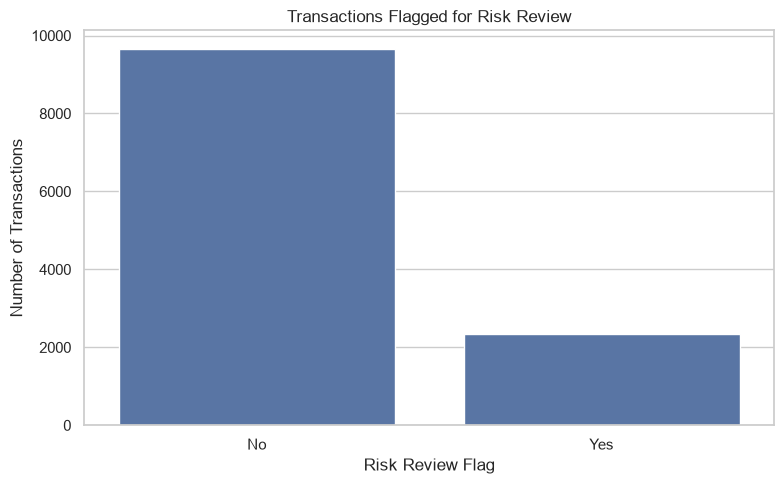

Risk_Review_Flag,No,Yes
Channel,,
ATM,78.82,21.18
Mobile App,80.60,19.40
POS,81.65,18.35
USSD,82.68,17.32
Web,78.65,21.35


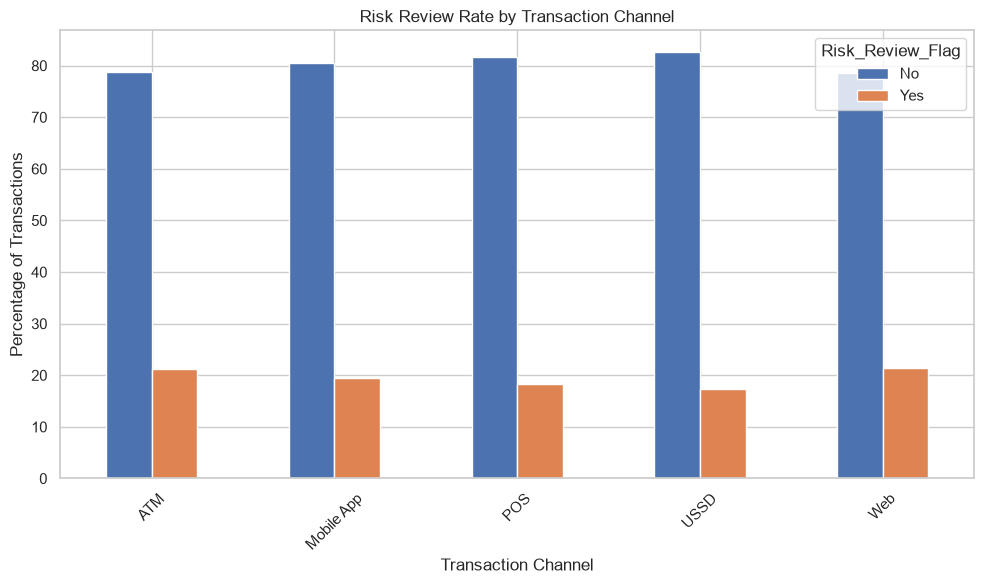

In [29]:
risk_col = "Risk_Review_Flag"

if risk_col in transactions.columns:
    display(transactions[risk_col].value_counts())

    plt.figure(figsize=(8, 5))
    sns.countplot(data=transactions, x=risk_col,
                  order=transactions[risk_col].value_counts().index)
    plt.title("Transactions Flagged for Risk Review")
    plt.xlabel("Risk Review Flag")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.show()

    if channel_col in transactions.columns:
        risk_by_channel = pd.crosstab(
            transactions[channel_col],
            transactions[risk_col],
            normalize="index"
        ) * 100

        display(risk_by_channel.round(2))

        risk_by_channel.plot(kind="bar", figsize=(10, 6))
        plt.title("Risk Review Rate by Transaction Channel")
        plt.xlabel("Transaction Channel")
        plt.ylabel("Percentage of Transactions")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Column not found:", risk_col)


### Interpretation

**What does the visual show?**  
The visual shows the number of transactions that were flagged for risk review compared with those that were not flagged. The majority of transactions were not flagged for risk review, while a smaller proportion were flagged. The channel-level analysis also shows that the risk-review rate differs across transaction channels, meaning that some channels have a higher proportion of transactions requiring review than others.

**Why is it important?**  
Risk-review patterns are important because they help FinTrust understand the level of potentially higher-risk activity within its transactions. Monitoring risk flags can help the bank identify unusual transaction patterns, strengthen fraud and risk controls, and determine which transaction channels may require closer monitoring.

**Business insight**  
The dataset shows that risk-reviewed transactions represent a smaller proportion of overall transaction activity, but the risk-review rate varies by transaction channel. This suggests that risk exposure is not necessarily uniform across all channels. FinTrust can investigate the channels with higher risk-review rates further by examining transaction amounts, transaction types, customer segments, and transaction status to identify factors associated with increased risk.
